In [22]:
import pandas as pd
import re
import os
from collections import defaultdict
import matplotlib.pyplot as plt

Overlap with neurosynth

In [8]:
# Read cognitive atlas
cognitive_atlas = pd.read_csv('cognitive_atlas_concepts_full.csv')
# Read Neurosynth
with open('data-neurosynth_version-4_vocab-terms_vocabulary.txt', 'r') as f:
    neurosynth_vocab = [line.strip() for line in f if line.strip()]

neurosynth_set = set(neurosynth_vocab)

overlaps = []
overlap_by_category = defaultdict(list)

for idx, row in cognitive_atlas.iterrows():
    category = row['Category']
    concept = row['Concept']

    if concept in neurosynth_set:
        overlaps.append({
            'Category': category,
            'Concept': concept,
            'Match_Type' : 'Exact Match',
            'Match_Words': concept
        })
        overlap_by_category[category].append(concept)
    else:
        concept_words = concept.lower().split()
        matched_words = [word for word in concept_words if word in neurosynth_set]

        if matched_words:
            overlaps.append({
                'Category': category,
                'Concept': concept,
                'Match_Type' : 'Partcial',
                'Match_Words': ','.join(matched_words)
            })

results_df = pd.DataFrame(overlaps)

# Print summary statistics
print("=" * 80)
print("OVERLAP ANALYSIS: Cognitive Atlas Concepts vs Neurosynth Vocabulary")
print("=" * 80)
print(f"\nTotal Cognitive Atlas concepts: {len(cognitive_atlas)}")
print(f"Total Neurosynth vocabulary terms: {len(neurosynth_vocab)}")
print(f"\nExact matches: {len([o for o in overlaps if o['Match_Type'] == 'Exact'])}")
print(f"Partial matches: {len([o for o in overlaps if o['Match_Type'] == 'Partial'])}")
print(f"Total concepts with matches: {len(results_df)}")

# Summary by category
print("\n" + "=" * 80)
print("EXACT MATCHES BY CATEGORY")
print("=" * 80)
exact_matches = results_df[results_df['Match_Type'] == 'Exact']
for category in sorted(exact_matches['Category'].unique()):
    cat_matches = exact_matches[exact_matches['Category'] == category]
    print(f"\n{category} ({len(cat_matches)} matches):")
    for concept in sorted(cat_matches['Concept'].values):
        print(f"  - {concept}")

# Save results to CSV
results_df.to_csv('cognitive_atlas_neurosynth_overlaps.csv', index=False)
print("\n" + "=" * 80)
print(f"Results saved to 'cognitive_atlas_neurosynth_overlaps.csv'")
print("=" * 80)


OVERLAP ANALYSIS: Cognitive Atlas Concepts vs Neurosynth Vocabulary

Total Cognitive Atlas concepts: 524
Total Neurosynth vocabulary terms: 3160

Exact matches: 0
Partial matches: 0
Total concepts with matches: 433

EXACT MATCHES BY CATEGORY

Results saved to 'cognitive_atlas_neurosynth_overlaps.csv'


In [20]:
import pandas as pd
from collections import defaultdict

# Read the Cognitive Atlas concepts CSV
cognitive_atlas = pd.read_csv('cognitive_atlas_concepts_full.csv')

# Read the Neurosynth vocabulary text file
with open('data-neurosynth_version-4_vocab-terms_vocabulary.txt', 'r') as f:
    neurosynth_vocab = [line.strip() for line in f if line.strip()]

# Convert neurosynth vocab to a set for faster lookup
neurosynth_set = set(neurosynth_vocab)

# Find overlaps
overlaps = []
overlap_by_category = defaultdict(list)

for idx, row in cognitive_atlas.iterrows():
    category = row['Category']
    concept = row['Concept']

    # Check if the full concept exists in neurosynth vocab
    if concept in neurosynth_set:
        overlaps.append({
            'Category': category,
            'Concept': concept,
            'Match_Type': 'Exact'
        })
        overlap_by_category[category].append(concept)
    else:
        # Check for partial matches (individual words)
        concept_words = concept.lower().split()
        matched_words = [word for word in concept_words if word in neurosynth_set]

        if matched_words:
            overlaps.append({
                'Category': category,
                'Concept': concept,
                'Match_Type': 'Partial',
                'Matched_Words': ', '.join(matched_words)
            })

# Create results dataframe
results_df = pd.DataFrame(overlaps)

# Print summary statistics
print("=" * 80)
print("OVERLAP ANALYSIS: Cognitive Atlas Concepts vs Neurosynth Vocabulary")
print("=" * 80)
print(f"\nTotal Cognitive Atlas concepts: {len(cognitive_atlas)}")
print(f"Total Neurosynth vocabulary terms: {len(neurosynth_vocab)}")
print(f"\nExact matches: {len([o for o in overlaps if o['Match_Type'] == 'Exact'])}")
print(f"Partial matches: {len([o for o in overlaps if o['Match_Type'] == 'Partial'])}")
print(f"Total concepts with matches: {len(results_df)}")

# Summary by category
print("\n" + "=" * 80)
print("EXACT MATCHES BY CATEGORY")
print("=" * 80)
exact_matches = results_df[results_df['Match_Type'] == 'Exact']
for category in sorted(exact_matches['Category'].unique()):
    cat_matches = exact_matches[exact_matches['Category'] == category]
    print(f"\n{category} ({len(cat_matches)} matches):")
    for concept in sorted(cat_matches['Concept'].values):
        print(f"  - {concept}")

# Collect all unique matched words from Neurosynth
matched_words_set = set()

# Add exact matches
exact_match_list = [o for o in overlaps if o['Match_Type'] == 'Exact']
for match in exact_match_list:
    matched_words_set.add(match['Concept'])

# Add words from partial matches
partial_match_list = [o for o in overlaps if o['Match_Type'] == 'Partial']
for match in partial_match_list:
    if 'Matched_Words' in match:
        words = [w.strip() for w in match['Matched_Words'].split(',')]
        matched_words_set.update(words)

# Save matched words to a separate file (one word per row)
with open('matched_neurosynth_words.txt', 'w') as f:
    for word in sorted(matched_words_set):
        f.write(word + '\n')

# Save results to CSV
results_df.to_csv('cognitive_atlas_neurosynth_overlaps.csv', index=False)

print("\n" + "=" * 80)
print(f"Results saved to 'cognitive_atlas_neurosynth_overlaps.csv'")
print(f"Matched Neurosynth words saved to 'matched_neurosynth_words.csv' ({len(matched_words_set)} unique words)")
print("=" * 80)

OVERLAP ANALYSIS: Cognitive Atlas Concepts vs Neurosynth Vocabulary

Total Cognitive Atlas concepts: 524
Total Neurosynth vocabulary terms: 3160

Exact matches: 71
Partial matches: 362
Total concepts with matches: 433

EXACT MATCHES BY CATEGORY

Action (4 matches):
  - action
  - motor control
  - movement
  - response selection

Attention (9 matches):
  - attention
  - distraction
  - fixation
  - focus
  - search
  - selective attention
  - spatial attention
  - sustained attention
  - visual attention

Emotion (9 matches):
  - anxiety
  - emotion
  - empathy
  - facial expression
  - fear
  - mood
  - pain
  - stress
  - valence

Executive/Cognitive Control (11 matches):
  - cognitive control
  - goal
  - inhibition
  - maintenance
  - manipulation
  - monitoring
  - planning
  - response conflict
  - response inhibition
  - updating
  - working memory

Language (12 matches):
  - language
  - language comprehension
  - meaning
  - morphology
  - naming
  - reading
  - semantic memor

find keywords in behavioral tests

Loading words from matched_neurosynth_words.txt...
Found 164 words to search for.

Loading category mapping from cognitive_atlas_concepts_full.csv...
Loaded 850 word-category mappings.

Found 132 file(s) in /Users/huilisun/Library/CloudStorage/OneDrive-PennO365/ControlCog/Activation/BehavTests/HBN_beha

Processing files...
  Reading: CIS_SR.csv
  Reading: WISC.csv
  Reading: KBIT.csv
  Reading: PMHS.csv
  Reading: CBCL_Pre.csv
  Reading: WAIS.csv
  Reading: ARI_SR.csv
  Reading: CFS.csv
  Reading: Peds_Migraine.csv
  Reading: FTQA.csv
  Reading: PreInt_EduHx.csv
  Reading: PhenX_School.csv
  Reading: ICU_SR.csv
  Reading: PreInt_Demos_Home.csv
  Reading: ESPAD.csv
  Reading: WASI.csv
  Reading: ASR.csv
  Reading: CELF_Full_9to21.csv
  Reading: DTS.csv
  Reading: Quotient_Ext.csv
  Reading: PhenX_Neighborhood.csv
  Reading: .DS_Store
  Reading: PANAS.csv
  Reading: Pregnancy.csv
  Reading: GSE.csv
  Reading: PPS.csv
  Reading: IUQ_SR.csv
  Reading: SRS_Pre.csv
  Reading: SCQ.csv
  Readi

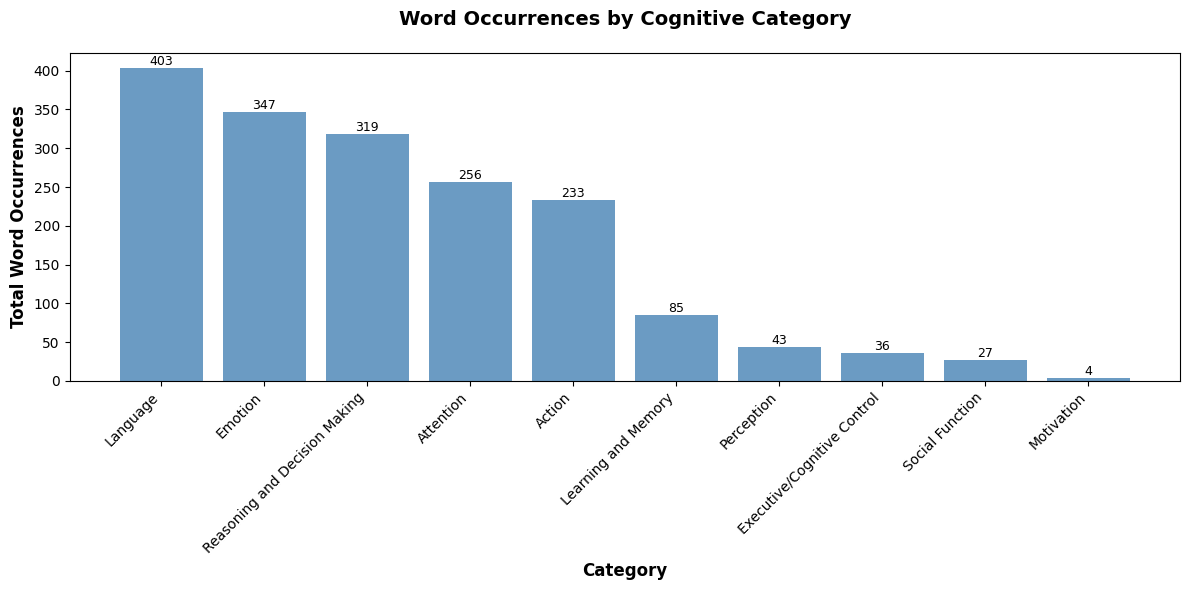


--- Category Summary ---
Language: 403 occurrences
Emotion: 347 occurrences
Reasoning and Decision Making: 319 occurrences
Attention: 256 occurrences
Action: 233 occurrences
Learning and Memory: 85 occurrences
Perception: 43 occurrences
Executive/Cognitive Control: 36 occurrences
Social Function: 27 occurrences
Motivation: 4 occurrences


In [29]:
# Paths - update these with your actual paths
WORDS_FILE = 'matched_neurosynth_words.txt'
DIRECTORY = '/Users/huilisun/Library/CloudStorage/OneDrive-PennO365/ControlCog/Activation/BehavTests/HBN_beha'
COGNITIVE_ATLAS_FILE = 'cognitive_atlas_concepts_full.csv'

def load_words(filepath):
    """Load words from txt file, one word per line."""
    with open(filepath, 'r', encoding='utf-8') as f:
        words = [line.strip().lower() for line in f if line.strip()]
    return words

def load_word_categories(cognitive_atlas_file):
    """Load word-to-category mapping from cognitive atlas CSV."""
    word_to_category = {}
    try:
        df = pd.read_csv(cognitive_atlas_file)
        for _, row in df.iterrows():
            concept = row['Concept'].lower()
            category = row['Category']
            word_to_category[concept] = category

            # Also map individual words from multi-word concepts
            for word in concept.split():
                if word not in word_to_category:
                    word_to_category[word] = category
    except Exception as e:
        print(f"Warning: Could not load category mapping: {e}")

    return word_to_category

def count_word_occurrences(text, words_to_find):
    """Count occurrences of each word in the text."""
    text_lower = text.lower()
    word_counts = defaultdict(int)

    for word in words_to_find:
        pattern = r'\b' + re.escape(word) + r'\b'
        matches = re.findall(pattern, text_lower)
        word_counts[word] = len(matches)

    return word_counts

def read_file_content(filepath):
    """Read content from a file based on its extension."""
    try:
        if filepath.endswith('.csv'):
            df = pd.read_csv(filepath)
            text = df.to_string(index=False)
            return text
        elif filepath.endswith(('.txt', '.text')):
            with open(filepath, 'r', encoding='utf-8') as f:
                return f.read()
        elif filepath.endswith(('.xlsx', '.xls')):
            df = pd.read_excel(filepath)
            text = df.to_string(index=False)
            return text
        else:
            with open(filepath, 'r', encoding='utf-8') as f:
                return f.read()
    except Exception as e:
        print(f"  Warning: Could not read {filepath}: {e}")
        return ""

def plot_category_histogram(word_counts, word_to_category):
    """Create histogram showing word occurrences by category."""
    category_counts = defaultdict(int)

    # Sum counts by category
    for word, count in word_counts.items():
        if count > 0:
            category = word_to_category.get(word, 'Unknown')
            category_counts[category] += count

    if not category_counts:
        print("No data to plot.")
        return

    # Sort categories by count
    categories = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)
    category_names = [c[0] for c in categories]
    counts = [c[1] for c in categories]

    # Create figure
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(category_names)), counts, color='steelblue', alpha=0.8)

    # Customize plot
    plt.xlabel('Category', fontsize=12, fontweight='bold')
    plt.ylabel('Total Word Occurrences', fontsize=12, fontweight='bold')
    plt.title('Word Occurrences by Cognitive Category', fontsize=14, fontweight='bold', pad=20)
    plt.xticks(range(len(category_names)), category_names, rotation=45, ha='right')

    # Add count labels on bars
    for i, (bar, count) in enumerate(zip(bars, counts)):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('category_word_counts_histogram.png', dpi=300, bbox_inches='tight')
    print("\nHistogram saved as 'category_word_counts_histogram.png'")
    plt.show()

    # Print category summary
    print("\n--- Category Summary ---")
    for category, count in categories:
        print(f"{category}: {count} occurrences")

def main():
    # Load words from txt file
    print(f"Loading words from {WORDS_FILE}...")
    words_to_find = load_words(WORDS_FILE)
    print(f"Found {len(words_to_find)} words to search for.")

    # Load word-to-category mapping
    print(f"\nLoading category mapping from {COGNITIVE_ATLAS_FILE}...")
    word_to_category = load_word_categories(COGNITIVE_ATLAS_FILE)
    print(f"Loaded {len(word_to_category)} word-category mappings.")

    # Check if directory exists
    if not os.path.exists(DIRECTORY):
        print(f"\nError: Directory '{DIRECTORY}' not found.")
        return

    # Get all files in directory
    all_files = [f for f in os.listdir(DIRECTORY) if os.path.isfile(os.path.join(DIRECTORY, f))]
    print(f"\nFound {len(all_files)} file(s) in {DIRECTORY}")

    if len(all_files) == 0:
        print("No files found in directory.")
        return

    # Collect all text from all files
    all_text = ""
    files_processed = 0

    print("\nProcessing files...")
    for filename in all_files:
        filepath = os.path.join(DIRECTORY, filename)
        print(f"  Reading: {filename}")

        content = read_file_content(filepath)
        if content:
            all_text += " " + content
            files_processed += 1

    print(f"\nSuccessfully processed {files_processed} file(s)")
    print(f"Total text length: {len(all_text)} characters")

    # Count word occurrences
    print("\nCounting word occurrences...")
    word_counts = count_word_occurrences(all_text, words_to_find)

    # Display results (only words with count > 0)
    print("\n--- Word Occurrence Counts (> 0) ---")
    words_found = 0
    for word in sorted(word_counts.keys()):
        if word_counts[word] > 0:
            print(f"{word}: {word_counts[word]}")
            words_found += 1

    if words_found == 0:
        print("No matching words found in the files.")
    else:
        print(f"\nTotal: {words_found} word(s) found")

    # Save results to CSV (only words with count > 0)
    output_file = 'word_counts.csv'
    results_df = pd.DataFrame(list(word_counts.items()),
                             columns=['Word', 'Count'])
    results_df = results_df[results_df['Count'] > 0]

    # Add category column
    results_df['Category'] = results_df['Word'].map(word_to_category).fillna('Unknown')
    results_df = results_df.sort_values('Count', ascending=False)
    results_df.to_csv(output_file, index=False)
    print(f"\nResults saved to {output_file}")

    # Create histogram
    if words_found > 0:
        print("\nGenerating category histogram...")
        plot_category_histogram(word_counts, word_to_category)

if __name__ == "__main__":
    main()